# Analyse Approfondie d'un Produit 

**Projet : Optimisation Prédictive de la Chaîne Logistique**


Cette analyse se place du point de vue d'un **gestionnaire de stock**. L'objectif est de comprendre finement le comportement des ventes du produit 1 afin d'optimiser les décisions d'approvisionnement. Nous étudions :
- La saisonnalité hebdomadaire (quel jour de la semaine vend-on le plus ?)
- La saisonnalité mensuelle (quels mois sont les plus actifs ?)
- La saisonnalité saisonnière (été, automne, hiver, printemps)

# 1. Chargement des données et préparation

On charge le dataset M5 et on extrait les ventes du produit 1 (première ligne). On associe ensuite chaque colonne `d_X` à une vraie date calendaire (à partir du 29 janvier 2011, date de début connue du dataset M5).

Produit analysé : FOODS_3_090
Période : 2011-01-29 → 2016-05-22
Total jours : 1941
Total ventes : 253859
        date  ventes  jour_semaine   nom_jour  mois  nom_mois  annee  semaine  \
0 2011-01-29     108             5   Saturday     1   January   2011        4   
1 2011-01-30     132             6     Sunday     1   January   2011        4   
2 2011-01-31     102             0     Monday     1   January   2011        5   
3 2011-02-01     120             1    Tuesday     2  February   2011        5   
4 2011-02-02     106             2  Wednesday     2  February   2011        5   

  saison  
0  Hiver  
1  Hiver  
2  Hiver  
3  Hiver  
4  Hiver  


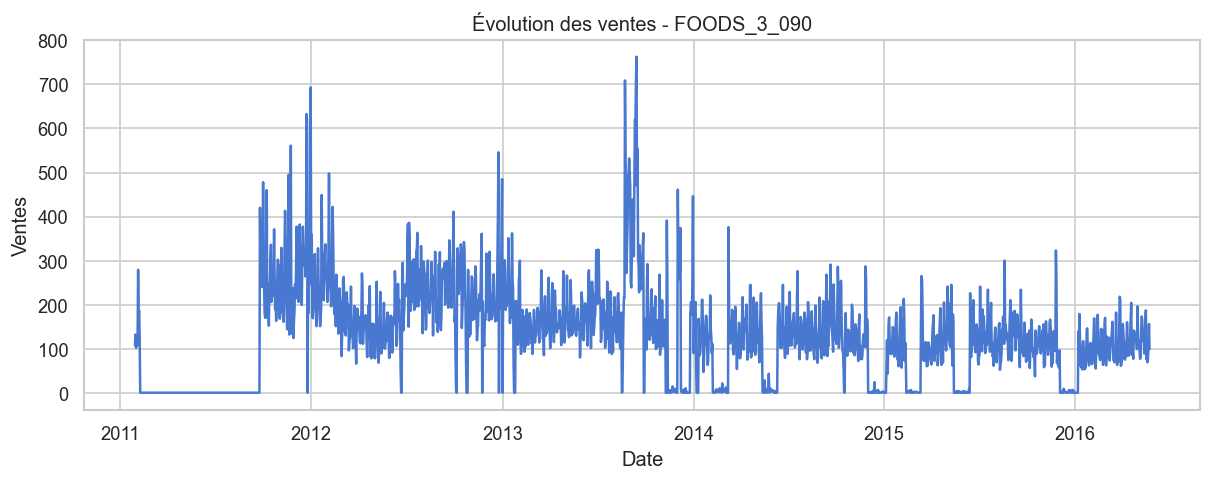

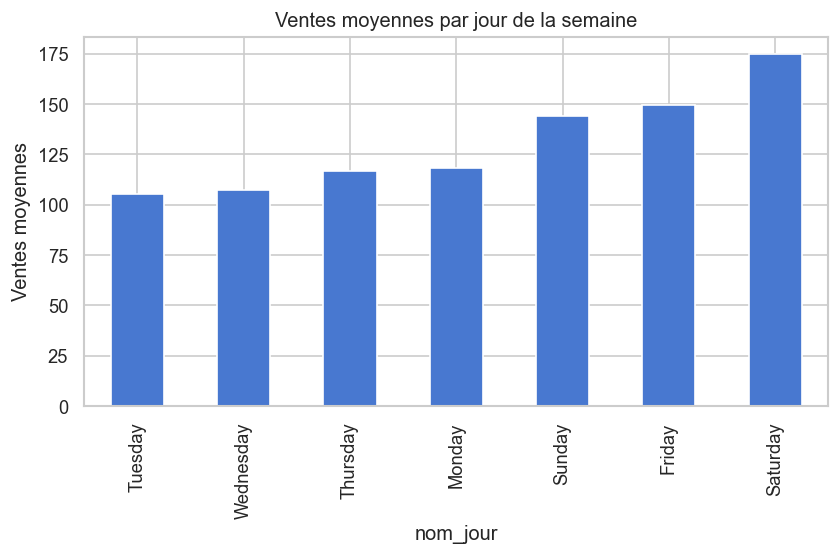

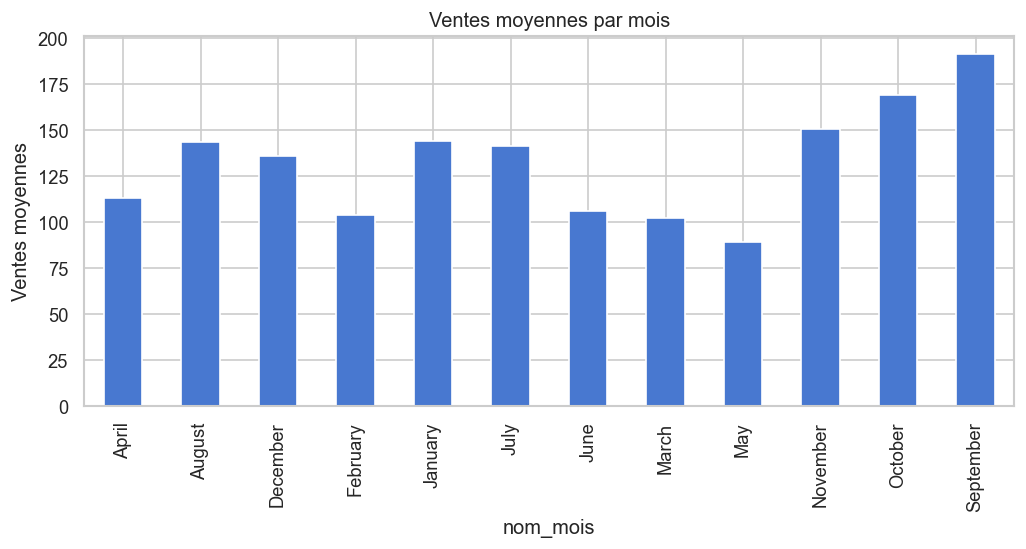

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120


df = pd.read_csv(r"C:\Users\marie\OneDrive - ESME\Bureau\sales_train_evaluation.csv")

colonnes_ventes = [c for c in df.columns if c.startswith("d_")]


df["total_ventes"] = df[colonnes_ventes].sum(axis=1)

df_top = df.sort_values("total_ventes", ascending=False)

produit1 = df_top.iloc[0]

ventes_p1 = produit1[colonnes_ventes].astype(int)


date_debut = pd.Timestamp("2011-01-29")
dates = pd.date_range(start=date_debut, periods=len(colonnes_ventes), freq="D")

ts = pd.DataFrame({
    "date": dates,
    "ventes": ventes_p1.values
})

ts["jour_semaine"] = ts["date"].dt.dayofweek
ts["nom_jour"] = ts["date"].dt.day_name()
ts["mois"] = ts["date"].dt.month
ts["nom_mois"] = ts["date"].dt.month_name()
ts["annee"] = ts["date"].dt.year
ts["semaine"] = ts["date"].dt.isocalendar().week.astype(int)

def get_saison(mois):
    if mois in [12, 1, 2]:
        return "Hiver"
    elif mois in [3, 4, 5]:
        return "Printemps"
    elif mois in [6, 7, 8]:
        return "Été"
    else:
        return "Automne"

ts["saison"] = ts["mois"].apply(get_saison)

nom_produit = produit1['item_id']

print(f"Produit analysé : {nom_produit}")
print(f"Période : {dates[0].date()} → {dates[-1].date()}")
print(f"Total jours : {len(ts)}")
print(f"Total ventes : {ts['ventes'].sum()}")

print(ts.head())

plt.figure(figsize=(12, 4))
plt.plot(ts["date"], ts["ventes"])
plt.title(f"Évolution des ventes - {nom_produit}")
plt.xlabel("Date")
plt.ylabel("Ventes")
plt.show()


moy_jour = ts.groupby("nom_jour")["ventes"].mean().sort_values()

plt.figure(figsize=(8,4))
moy_jour.plot(kind="bar")
plt.title("Ventes moyennes par jour de la semaine")
plt.ylabel("Ventes moyennes")
plt.show()

moy_mois = ts.groupby("nom_mois")["ventes"].mean()

plt.figure(figsize=(10,4))
moy_mois.plot(kind="bar")
plt.title("Ventes moyennes par mois")
plt.ylabel("Ventes moyennes")
plt.show()

# 2. Vue d'ensemble évolution des ventes dans le temps


Avant d'aller dans le détail, on observe la série temporelle complète du produit 1, avec un lissage sur 30 jours pour mieux visualiser la tendance.

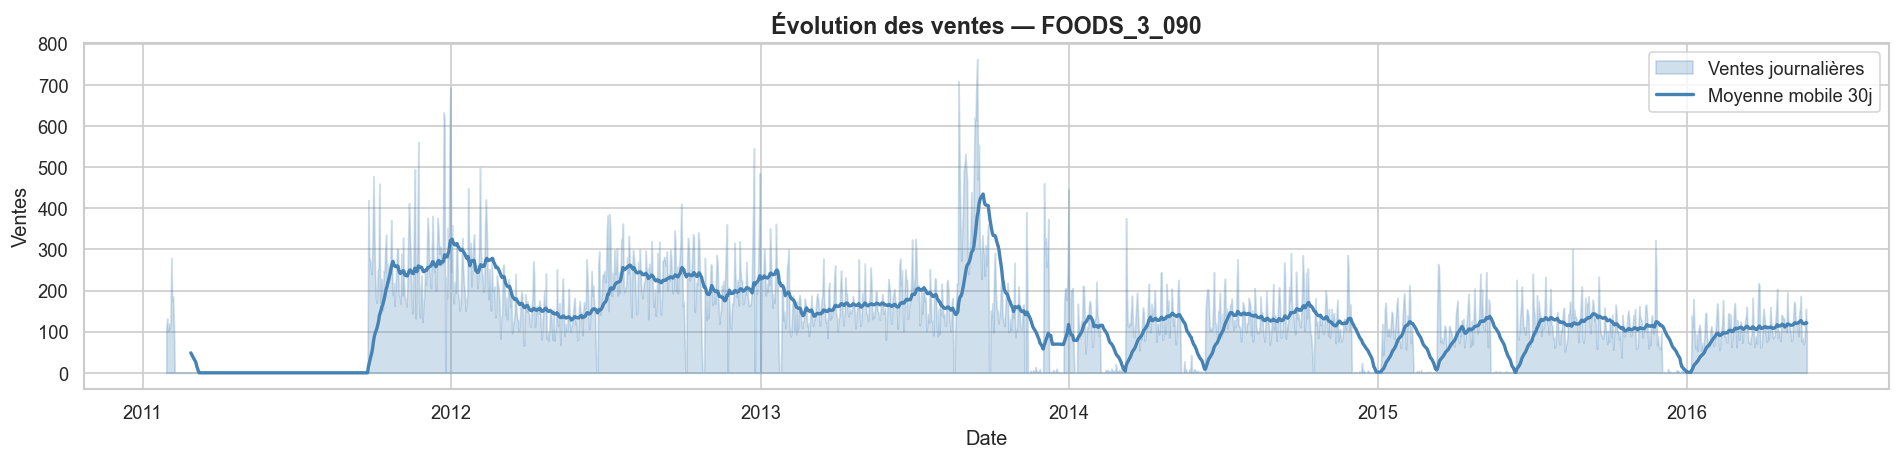

Taux de jours sans vente : 18.5%
Ventes max sur 1 jour    : 763
Ventes moyennes par jour : 130.79


In [24]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.fill_between(ts["date"], ts["ventes"], alpha=0.25, color="steelblue", label="Ventes journalières")
ax.plot(ts["date"], ts["ventes"].rolling(30).mean(), color="steelblue", linewidth=2, label="Moyenne mobile 30j")

ax.set_title(f"Évolution des ventes — {nom_produit}", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Ventes")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Taux de jours sans vente : {(ts['ventes']==0).mean()*100:.1f}%")
print(f"Ventes max sur 1 jour    : {ts['ventes'].max()}")
print(f"Ventes moyennes par jour : {ts['ventes'].mean():.2f}")

# 3. Saisonnalité hebdomadaire : Quel jour de la semaine vend-on le plus ?


En tant que gestionnaire de stock, savoir quel jour de la semaine génère le plus de ventes est crucial pour planifier les réassorts. On calcule la somme et la moyenne des ventes selon le jour de la semaine.

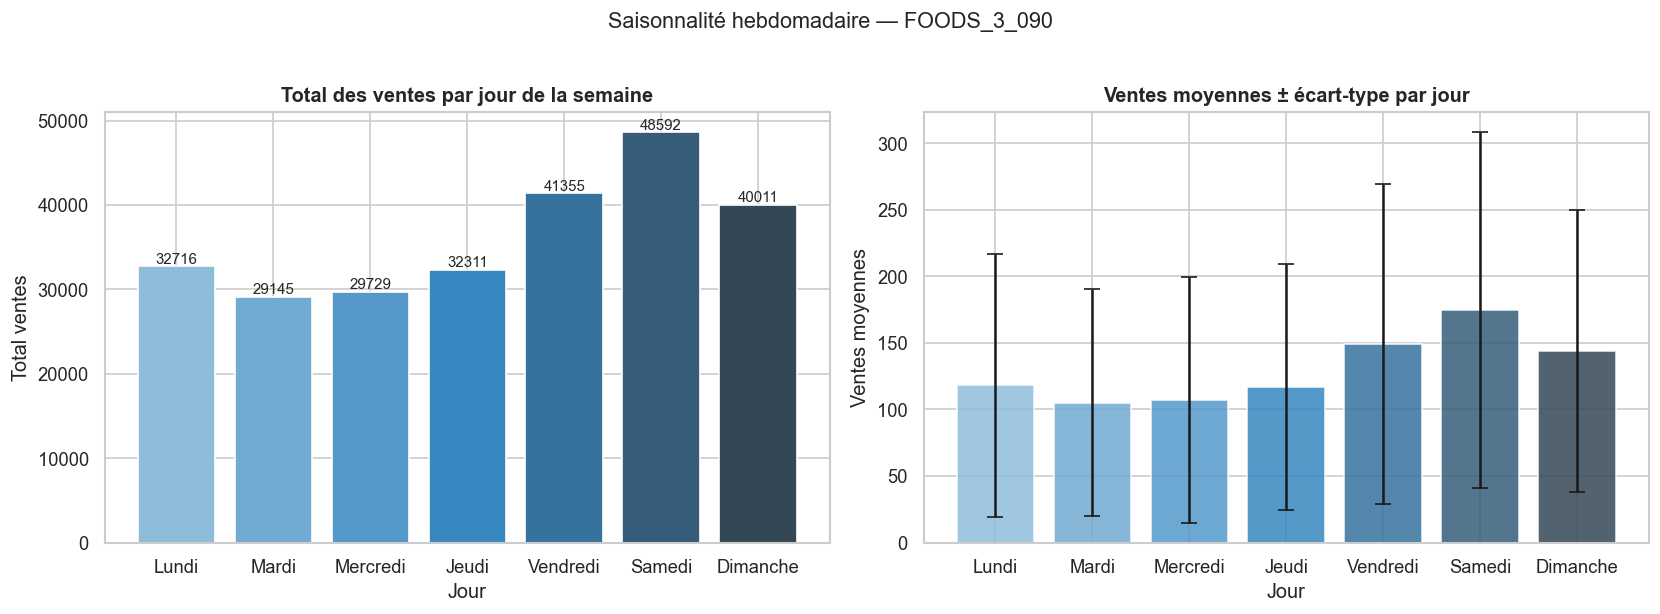


Tableau récapitulatif :
            sum    mean     std
Lundi     32716  118.11   99.06
Mardi     29145  105.22   85.39
Mercredi  29729  107.32   92.51
Jeudi     32311  116.65   92.46
Vendredi  41355  149.30  120.11
Samedi    48592  174.79  133.46
Dimanche  40011  143.92  106.10


In [32]:
ordre_jours = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
labels_fr   = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

hebdo = ts.groupby(ts["date"].dt.day_name())["ventes"].agg(["sum", "mean", "std"]).reindex(ordre_jours)
hebdo.index = labels_fr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette("Blues_d", 7)
bars = axes[0].bar(hebdo.index, hebdo["sum"], color=colors)
axes[0].set_title("Total des ventes par jour de la semaine", fontweight="bold")
axes[0].set_ylabel("Total ventes")
axes[0].set_xlabel("Jour")
for bar, val in zip(bars, hebdo["sum"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(int(val)),
                 ha='center', va='bottom', fontsize=9)

# Moyenne + écart-type
axes[1].bar(hebdo.index, hebdo["mean"], yerr=hebdo["std"], capsize=5, color=colors, alpha=0.85)
axes[1].set_title("Ventes moyennes ± écart-type par jour", fontweight="bold")
axes[1].set_ylabel("Ventes moyennes")
axes[1].set_xlabel("Jour")

plt.suptitle(f"Saisonnalité hebdomadaire — {nom_produit}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nTableau récapitulatif :")
print(hebdo.round(2).to_string())

# 4. Saisonnalité mensuelle :  Ventes moyennes par jour selon le mois


Ici on répond précisément à la question du professeur : pour chaque mois de l'année, quelle est la vente moyenne selon le jour de la semaine ? Cela permet, par exemple, de savoir qu'un lundi de janvier génère en moyenne X ventes, contre Y ventes un lundi d'août.

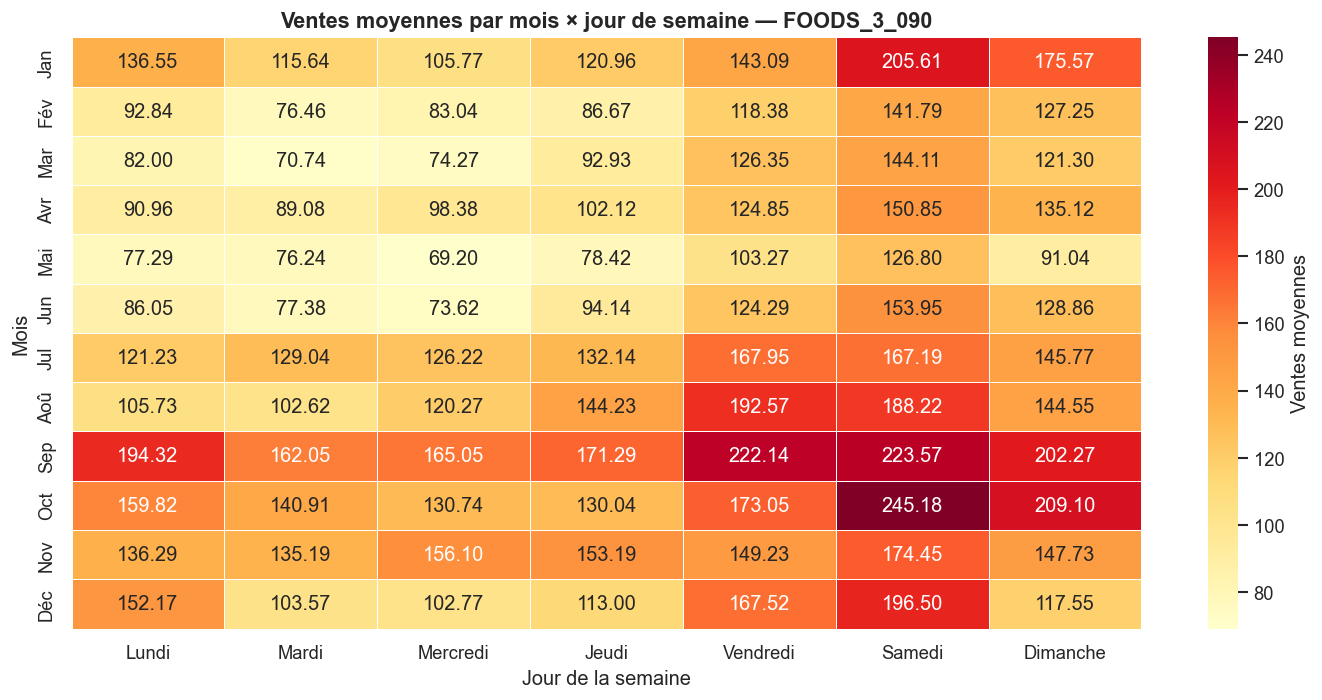

In [27]:
ts["nom_jour_en"] = ts["date"].dt.day_name()
pivot = ts.pivot_table(values="ventes", index="mois", columns="nom_jour_en", aggfunc="mean")
pivot = pivot[ordre_jours]
pivot.index = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
pivot.columns = labels_fr

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Ventes moyennes"})
ax.set_title(f"Ventes moyennes par mois × jour de semaine — {nom_produit}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Jour de la semaine")
ax.set_ylabel("Mois")
plt.tight_layout()
plt.show()

# 5. Saisonnalité mensuelle — Ventes totales et moyennes par mois

On regarde maintenant le volume total de ventes pour chaque mois, en agrégeant toutes les années disponibles. Cela révèle les mois de forte et faible activité.

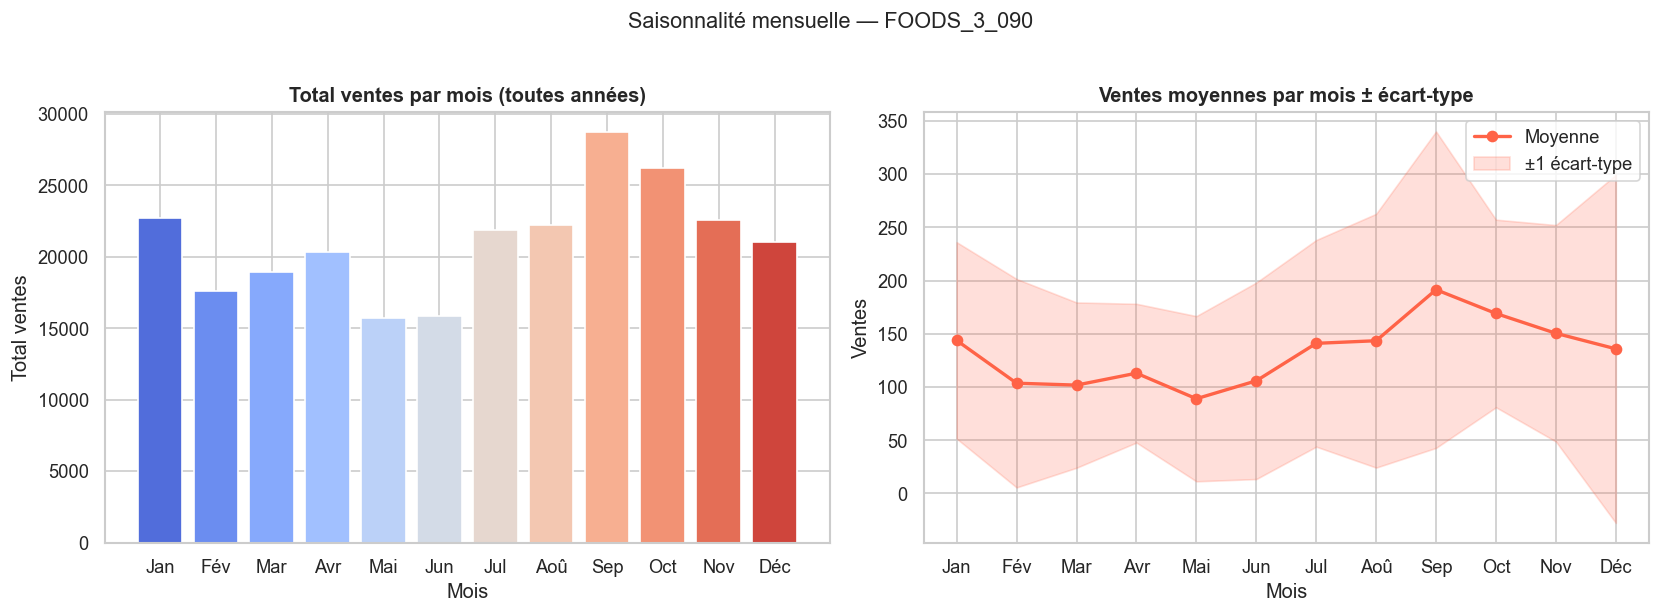

In [28]:
noms_mois_fr = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
mensuel = ts.groupby("mois")["ventes"].agg(["sum","mean","std"])
mensuel.index = noms_mois_fr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette("coolwarm", 12)
axes[0].bar(mensuel.index, mensuel["sum"], color=palette)
axes[0].set_title("Total ventes par mois (toutes années)", fontweight="bold")
axes[0].set_ylabel("Total ventes")
axes[0].set_xlabel("Mois")

axes[1].plot(mensuel.index, mensuel["mean"], marker="o", color="tomato", linewidth=2, label="Moyenne")
axes[1].fill_between(mensuel.index,
                     mensuel["mean"] - mensuel["std"],
                     mensuel["mean"] + mensuel["std"],
                     alpha=0.2, color="tomato", label="±1 écart-type")
axes[1].set_title("Ventes moyennes par mois ± écart-type", fontweight="bold")
axes[1].set_ylabel("Ventes")
axes[1].set_xlabel("Mois")
axes[1].legend()

plt.suptitle(f"Saisonnalité mensuelle — {nom_produit}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 6. Saisonnalité saisonnière — Été, Automne, Hiver, Printemps

On regroupe les mois par saison pour répondre à la question : ce produit est-il plus demandé l'été ou l'hiver ? Cette information est précieuse pour le gestionnaire de stock afin d'anticiper les réassorts saisonniers.

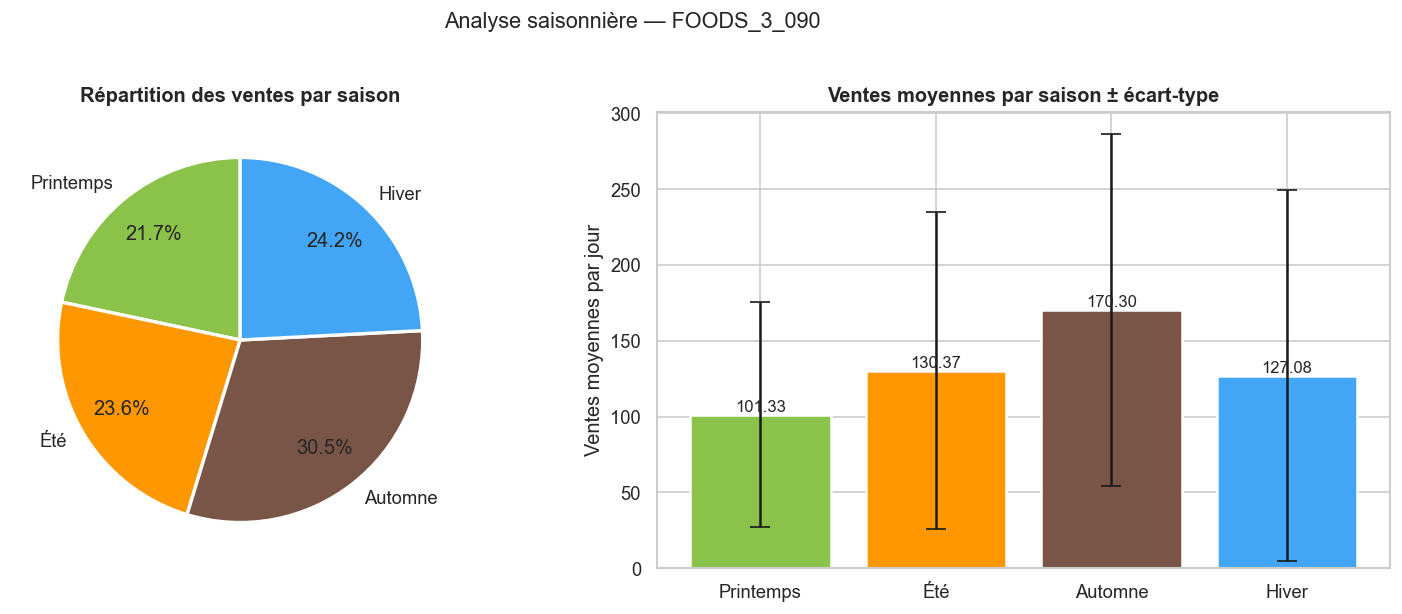


Récapitulatif par saison :
             sum     mean      std
saison                            
Printemps  55023  101.331   74.226
Été        59969  130.367  104.799
Automne    77486  170.299  116.409
Hiver      61381  127.083  122.419


In [30]:
ordre_saisons = ["Printemps", "Été", "Automne", "Hiver"]
saison_stats  = ts.groupby("saison")["ventes"].agg(["sum","mean","std"]).reindex(ordre_saisons)

couleurs_saisons = ["#8BC34A", "#FF9800", "#795548", "#42A5F5"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(saison_stats["sum"], labels=ordre_saisons, colors=couleurs_saisons,
            autopct="%1.1f%%", startangle=90, pctdistance=0.75,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Répartition des ventes par saison", fontweight="bold")

bars = axes[1].bar(ordre_saisons, saison_stats["mean"], yerr=saison_stats["std"],
                   capsize=6, color=couleurs_saisons, edgecolor="white", linewidth=1.5)
axes[1].set_title("Ventes moyennes par saison ± écart-type", fontweight="bold")
axes[1].set_ylabel("Ventes moyennes par jour")
for bar, val in zip(bars, saison_stats["mean"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=10)

plt.suptitle(f"Analyse saisonnière — {nom_produit}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nRécapitulatif par saison :")
print(saison_stats.round(3).to_string())

## 7. Profil hebdomadaire par saison

On combine les deux analyses précédentes : le comportement jour-par-jour change-t-il selon la saison ? Ce graphique permet au gestionnaire de stock de savoir si un samedi d'été est plus ou moins chargé qu'un samedi d'hiver.

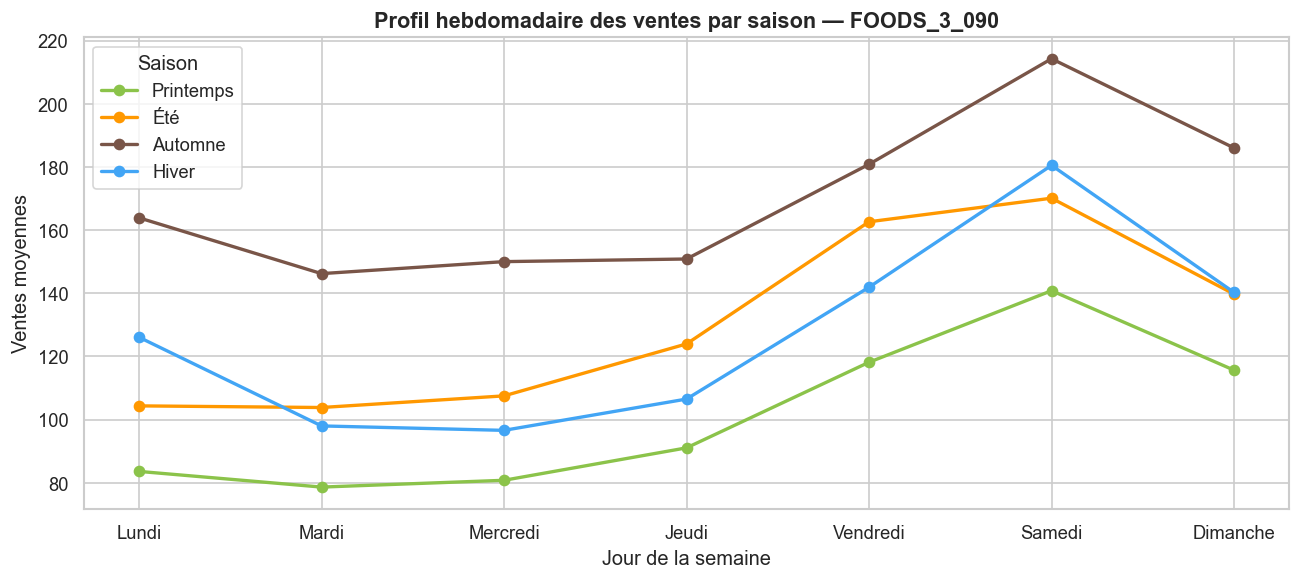

In [31]:
pivot_saison_jour = ts.pivot_table(values="ventes", index="saison",
                                    columns="nom_jour_en", aggfunc="mean")
pivot_saison_jour = pivot_saison_jour[ordre_jours]
pivot_saison_jour.columns = labels_fr
pivot_saison_jour = pivot_saison_jour.reindex(ordre_saisons)

fig, ax = plt.subplots(figsize=(11, 5))
for saison, color in zip(ordre_saisons, couleurs_saisons):
    ax.plot(labels_fr, pivot_saison_jour.loc[saison], marker="o", label=saison,
            color=color, linewidth=2)

ax.set_title(f"Profil hebdomadaire des ventes par saison — {nom_produit}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Jour de la semaine")
ax.set_ylabel("Ventes moyennes")
ax.legend(title="Saison")
plt.tight_layout()
plt.show()